# TraceME Pipeline — Quickstart

`traceme-pipeline` runs SAM2 (or SAM3) video-object tracking over a folder of
frames, given point/box prompts that seed each object. It produces:

- a merged **CSV** of per-frame, per-object stats (area, centroid, bbox),
- a merged **annotated MP4**,
- optionally, the raw per-object **masks** for shape analysis,
- a **run summary** JSON (status, processed/resumed/failed chunks).

This notebook builds a tiny synthetic clip end-to-end and exercises the whole
surface: CLI, Python API, output inspection, mask reload, resume, and batch
task generation. It's self-contained — everything runs in a temp directory,
no external data required.

**Contents**
1. Setup
2. Synthetic input frames
3. Prompt YAML
4. Run — CLI
5. Run — Python API (with `--save-masks`)
6. Run summary
7. Inspect the merged CSV
8. The `-1` lost-mask sentinel
9. Watch the annotated video
10. Reload saved masks
11. Resume behavior
12. Batch runs with `traceme-gen-tasks`


## 1. Setup

```
pip install traceme-pipeline
```

TraceME auto-downloads the SAM2 checkpoint it needs on first use (cached at
`~/.cache/traceme/sam2/checkpoints`). This notebook uses `--model tiny` — the
smallest/fastest SAM2 size — so it runs in well under a minute on CPU; the
package default is `large` for real (accuracy-sensitive) work. See the
README's "Configure SAM2" section for `SAM2_ROOT` / `SAM2_CHECKPOINT_DIR` if
your checkpoints live elsewhere (e.g. a shared cluster mount), and the SAM3
section if you want to run `--model sam3` instead.


In [1]:
import json
import os
import tempfile
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Video, display

# Fastest SAM2 size, for a quick demo. Unset this (or pass --model large) for
# real runs — see the README's model-selection section.
os.environ.setdefault("SAM2_MODEL", "tiny")

import torch

from traceme.sam2 import config as sam2_config

print(f"model={sam2_config.MODEL}  device={sam2_config.device}  torch={torch.__version__}")


model=tiny  device=cpu  torch=2.9.0+cu128


## 2. Synthetic input frames

Two small squares on a dark background, each drifting in a straight line and
staying fully in-frame for all 12 frames — enough to exercise chunking
(`chunk_size=6`, so this clip spans 3 chunks with 1 frame of overlap) and
multi-object tracking without relying on real video data.


Wrote 12 frames (160x160) to /tmp/traceme_quickstart_spot1hx0/clipA


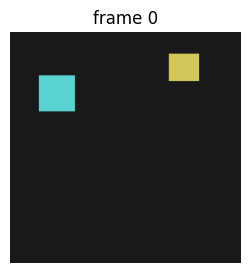

In [2]:
work_dir = Path(tempfile.mkdtemp(prefix="traceme_quickstart_"))
frame_dir = work_dir / "clipA"
frame_dir.mkdir(parents=True)

N_FRAMES = 12
SIZE = 160


def make_frame(i: int) -> np.ndarray:
    img = np.full((SIZE, SIZE, 3), 25, dtype=np.uint8)
    x1 = 20 + i * 6
    cv2.rectangle(img, (x1, 30), (x1 + 24, 54), (210, 210, 90), -1)   # obj 1: drifts right
    y2 = 15 + i * 8
    cv2.rectangle(img, (110, y2), (130, y2 + 18), (90, 200, 210), -1)  # obj 2: drifts down
    return img


for i in range(N_FRAMES):
    cv2.imwrite(str(frame_dir / f"{i:05d}.jpg"), make_frame(i))

print(f"Wrote {N_FRAMES} frames ({SIZE}x{SIZE}) to {frame_dir}")
plt.figure(figsize=(3, 3))
plt.imshow(cv2.cvtColor(make_frame(0), cv2.COLOR_BGR2RGB))
plt.title("frame 0")
plt.axis("off")
plt.show()


## 3. Prompt YAML

One point prompt per object on frame 0 — `labels: [1]` marks it as a
positive (foreground) point. See `src/traceme/prompts/parser.py` for the
full schema (boxes, negative points, polygons).


In [3]:
prompts_path = work_dir / "prompts.yaml"
prompts_path.write_text(
    "prompts:\n"
    "  - {frame_idx: 0, obj_id: 1, points: [[32, 42]], labels: [1]}\n"
    "  - {frame_idx: 0, obj_id: 2, points: [[120, 24]], labels: [1]}\n"
)
print(prompts_path.read_text())


prompts:
  - {frame_idx: 0, obj_id: 1, points: [[32, 42]], labels: [1]}
  - {frame_idx: 0, obj_id: 2, points: [[120, 24]], labels: [1]}



In [4]:
# Parsing is validated the same way the pipeline validates it internally —
# useful for sanity-checking a hand-written prompt file before a long run.
from traceme.prompts.parser import YamlPromptParser

for p in YamlPromptParser(prompts_path).load(strict_keys=True):
    print(p)


Prompt(frame_idx=0, obj_id=1, box=None, points=((32, 42),), labels=(1,), polygon=None)
Prompt(frame_idx=0, obj_id=2, box=None, points=((120, 24),), labels=(1,), polygon=None)


## 4. Run — CLI

The normal way to run TraceME: one command per clip.


In [5]:
output_cli = work_dir / "out_cli"
!traceme -i {frame_dir} -o {output_cli} -p {prompts_path} --model tiny -c 6 --overlap 1 --fps 8


15:41:19 | INFO    | clipA | job=- | traceme.pipeline | pid=27396 host=uhh-lp | Pipeline config: frame_dir=/tmp/traceme_quickstart_spot1hx0/clipA output=/tmp/traceme_quickstart_spot1hx0/out_cli prompt=/tmp/traceme_quickstart_spot1hx0/prompts.yaml chunk_size=6 overlap=1 fps=8 chunk_mode=auto model=tiny del_tmp=False


15:41:20 | INFO    | clipA | job=- | traceme.pipeline | pid=27396 host=uhh-lp | Runtime: torch=2.9.0+cu128 cuda=12.8 cudnn=91002 visible_gpus=<unset>
15:41:20 | INFO    | clipA | job=- | traceme.pipeline | pid=27396 host=uhh-lp | Runtime: no CUDA GPUs visible
15:41:20 | INFO    | clipA | job=- | traceme.pipeline | pid=27396 host=uhh-lp | Model config: model=tiny cfg=/home/steve/exp/lib/python3.12/site-packages/sam2/configs/sam2.1/sam2.1_hiera_t.yaml ckpt=/home/steve/.cache/traceme/sam2/checkpoints/sam2.1_hiera_tiny.pt
15:41:20 | INFO    | clipA | job=- | traceme.pipeline | pid=27396 host=uhh-lp | Precision: device=cpu tf32=False bf16=False
15:41:20 | INFO    | clipA | job=- | traceme.video.chunker | pid=27396 host=uhh-lp | chunk_frames(mode=auto) | chunk_size=6 | overlap=1 | action=symlink | frames_detected=12
15:41:20 | INFO    | clipA | job=- | traceme.video.chunker | pid=27396 host=uhh-lp | Building chunks from 12 frames (chunk_size=6, overlap=1)
15:41:20 | INFO    | clipA | job=- |

15:41:21 | INFO    | clipA | job=- | root | pid=27396 host=uhh-lp | Loaded checkpoint sucessfully
15:41:21 | INFO    | clipA | job=- | traceme.sam2.runner | pid=27396 host=uhh-lp | Build predictor finished in 0.349s
frame loading (JPEG):   0%|                               | 0/6 [00:00<?, ?it/s]

frame loading (JPEG): 100%|███████████████████████| 6/6 [00:00<00:00, 37.67it/s]


/home/steve/exp/lib/python3.12/site-packages/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/home/steve/exp/lib/python3.12/site-packages/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


...

propagate in video:  86%|█████████████████████▍   | 6/7 [00:21<00:04,  4.04s/it]

propagate in video: 100%|█████████████████████████| 7/7 [00:28<00:00,  4.09s/it]
15:42:15 | INFO    | clipA | job=- | traceme.sam2.runner | pid=27396 host=uhh-lp | [chunk 001] propagate_and_collect finished in 29.001s
15:42:15 | INFO    | clipA | job=- | traceme.sam2.runner | pid=27396 host=uhh-lp | [chunk 001] wrote seeds → seed_chunk_001.npz (frames=1)
15:42:15 | INFO    | clipA | job=- | traceme.sam2.runner | pid=27396 host=uhh-lp | [chunk 001] write_overlap_seeds finished in 0.002s


15:42:15 | INFO    | - | job=- | traceme.sam2.runner | pid=27396 host=uhh-lp | [chunk 001] wrote clipA_chunk_001.csv (frames=7, objs=14)
15:42:15 | INFO    | - | job=- | traceme.sam2.runner | pid=27396 host=uhh-lp | [chunk 001] write_csv finished in 0.011s
15:42:15 | INFO    | - | job=- | traceme.sam2.runner | pid=27396 host=uhh-lp | [chunk 001] wrote clipA_chunk_001.mp4
15:42:15 | INFO    | - | job=- | traceme.sam2.runner | pid=27396 host=uhh-lp | [chunk 001] render_video finished in 0.010s
15:42:15 | INFO    | - | job=- | traceme.sam2.runner | pid=27396 host=uhh-lp | [OK] chunk 001 complete


15:42:15 | INFO    | clipA | job=- | traceme.sam2.runner | pid=27396 host=uhh-lp | Run complete: frames=13, objects=26, chunks=2 (processed=2, resumed=0, failed=0)
15:42:15 | INFO    | clipA | job=- | traceme.pipeline | pid=27396 host=uhh-lp | SAM2 run finished in 54.605s
15:42:15 | INFO    | clipA | job=- | traceme.video.merge | pid=27396 host=uhh-lp | Merging 2 CSV files...
15:42:15 | INFO    | clipA | job=- | traceme.video.merge | pid=27396 host=uhh-lp | [OK] Merged 2 chunk files → clipA.csv (24 rows, 12 unique frames)
15:42:15 | INFO    | clipA | job=- | traceme.pipeline | pid=27396 host=uhh-lp | Merging chunk CSVs finished in 0.012s
15:42:15 | INFO    | clipA | job=- | traceme.video.merge | pid=27396 host=uhh-lp | ffmpeg concat → clipA.mp4


15:42:15 | INFO    | clipA | job=- | traceme.video.merge | pid=27396 host=uhh-lp | [OK] merged video written: clipA.mp4
15:42:15 | INFO    | clipA | job=- | traceme.pipeline | pid=27396 host=uhh-lp | Merging chunk videos finished in 0.063s
15:42:15 | INFO    | clipA | job=- | traceme.pipeline | pid=27396 host=uhh-lp | Writing run summary finished in 0.000s
15:42:15 | INFO    | clipA | job=- | traceme.pipeline | pid=27396 host=uhh-lp | Pipeline finished successfully.


In [6]:
sorted(p.name for p in output_cli.iterdir())


['clipA.csv', 'clipA.mp4', 'clipA_run_summary.json', 'clipA_tmp']

## 5. Run — Python API (with `--save-masks`)

Equivalent to the CLI call above, but embeddable directly in a script or
notebook — useful when the pipeline is one step in a larger workflow. This
run also passes `save_masks=True` to additionally persist every object's
binary mask (see step 10).


In [7]:
from traceme.pipeline import PipelineConfig, PipelinePaths, run_pipeline

output_api = work_dir / "out_api"
cfg = PipelineConfig(
    frame_dir=frame_dir,
    output_folder=output_api,
    prompt_file=prompts_path,
    chunk_size=6,
    overlap=1,
    fps=8,
    model="tiny",
    save_masks=True,
)
paths = PipelinePaths.from_config(cfg)
run_pipeline(cfg)
sorted(p.name for p in output_api.iterdir())


15:42:16 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Pipeline config: frame_dir=/tmp/traceme_quickstart_spot1hx0/clipA output=/tmp/traceme_quickstart_spot1hx0/out_api prompt=/tmp/traceme_quickstart_spot1hx0/prompts.yaml chunk_size=6 overlap=1 fps=8 chunk_mode=auto model=tiny del_tmp=False


15:42:16 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Runtime: torch=2.9.0+cu128 cuda=12.8 cudnn=91002 visible_gpus=<unset>


15:42:16 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Runtime: no CUDA GPUs visible


15:42:16 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Model config: model=tiny cfg=/home/steve/exp/lib/python3.12/site-packages/sam2/configs/sam2.1/sam2.1_hiera_t.yaml ckpt=/home/steve/.cache/traceme/sam2/checkpoints/sam2.1_hiera_tiny.pt


15:42:16 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Precision: device=cpu tf32=False bf16=False


...

15:43:32 | INFO    | clipA | job=- | traceme.video.merge | pid=27350 host=uhh-lp | [OK] Merged 2 chunk archives → clipA_masks.npz (24 mask entries)


15:43:32 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Merging chunk masks finished in 0.008s


15:43:32 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Writing run summary finished in 0.000s


15:43:32 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Pipeline finished successfully.


['clipA.csv',
 'clipA.mp4',
 'clipA_masks.npz',
 'clipA_run_summary.json',
 'clipA_tmp']

## 6. Run summary

In [8]:
summary = json.loads(paths.run_summary.read_text())
summary


{'status': 'complete',
 'finished_at': '2026-07-29T13:43:32.381518+00:00',
 'total_chunks': 2,
 'processed_chunks': [0, 1],
 'resumed_chunks': [],
 'failed_chunks': [],
 'total_frames': 13,
 'total_objects': 26,
 'config': {'frame_dir': '/tmp/traceme_quickstart_spot1hx0/clipA',
  'output_folder': '/tmp/traceme_quickstart_spot1hx0/out_api',
  'prompt_file': '/tmp/traceme_quickstart_spot1hx0/prompts.yaml',
  'chunk_size': 6,
  'overlap': 1,
  'fps': 8,
  'chunk_mode': 'auto',
  'model': 'tiny',
  'resume': True,
  'save_masks': True}}

## 7. Inspect the merged CSV

Columns: `chunk_id, global_frame_idx, in_chunk_idx, obj_id, area_px,
centroid_x, centroid_y, bbox_x, bbox_y, bbox_w, bbox_h`. Every tracked object
gets one row per frame.


In [9]:
df = pd.read_csv(paths.merged_csv)
df.head(10)


,chunk_id,global_frame_idx,in_chunk_idx,obj_id,area_px,centroid_x,centroid_y,bbox_x,bbox_y,bbox_w,bbox_h
0,0,0,0,1,625,32.00,42.00,20,30,25,25
1,0,0,0,2,399,120.00,24.00,110,15,21,19
2,0,1,1,1,625,38.00,42.00,26,30,25,25
3,0,1,1,2,415,119.61,32.14,109,23,22,20
4,0,2,2,1,625,44.00,42.00,32,30,25,25
5,0,2,2,2,425,119.73,40.44,109,31,22,20
6,0,3,3,1,625,50.00,42.00,38,30,25,25
7,0,3,3,2,400,119.97,48.00,109,39,22,19
8,0,4,4,1,625,56.00,42.00,44,30,25,25
9,0,4,4,2,418,119.99,56.42,109,47,22,20


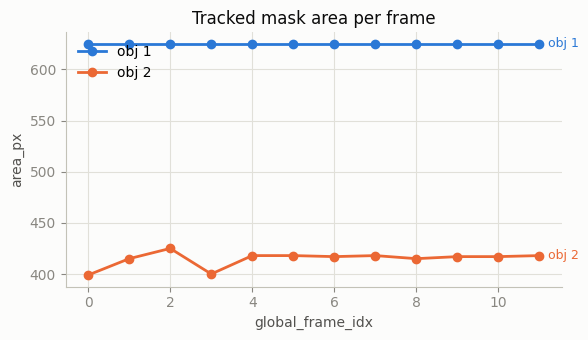

In [10]:
tracked = df.dropna(subset=["obj_id"]).copy()
tracked["obj_id"] = tracked["obj_id"].astype(int)

# Validated categorical palette, slots 1 & 2 (blue/orange) — passes CVD +
# normal-vision separation checks; fixed hue-per-entity, not cycled.
colors = {1: "#2a78d6", 2: "#eb6834"}

fig, ax = plt.subplots(figsize=(6, 3.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
for oid, g in tracked.groupby("obj_id"):
    g = g.sort_values("global_frame_idx")
    ax.plot(
        g["global_frame_idx"], g["area_px"],
        color=colors[oid], linewidth=2, marker="o", markersize=6, label=f"obj {oid}",
    )
    ax.annotate(
        f"obj {oid}", (g["global_frame_idx"].iloc[-1], g["area_px"].iloc[-1]),
        xytext=(6, 0), textcoords="offset points", color=colors[oid],
        fontsize=9, va="center",
    )

ax.set_xlabel("global_frame_idx", color="#52514e")
ax.set_ylabel("area_px", color="#52514e")
ax.set_title("Tracked mask area per frame", color="#0b0b0b")
ax.grid(True, color="#e1e0d9", linewidth=0.8)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")
ax.tick_params(colors="#898781")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


## 8. The `-1` lost-mask sentinel

Two distinct "nothing here" cases show up in the CSV:

- a **frame with no tracked objects at all** → one row, blank `obj_id`, `area_px=0`.
- an **object that's being tracked but whose mask vanished** (the model
  predicted an empty mask for it, this frame) → every stat column is `-1`,
  distinguishing "lost" from a legitimately absent object.

Both synthetic objects stay fully in-frame here, so nothing gets lost in this
run's CSV (`tracked[tracked.area_px == -1]` below is empty) — the cell after
it calls the low-level writer directly to show what a lost-mask row looks
like deterministically.


In [11]:
tracked[tracked["area_px"] == -1]


,chunk_id,global_frame_idx,in_chunk_idx,obj_id,area_px,centroid_x,centroid_y,bbox_x,bbox_y,bbox_w,bbox_h


In [12]:
from traceme.sam2.io import _write_csv_for_chunk

demo_csv = work_dir / "lost_mask_demo.csv"
stats_per_frame = {
    0: {1: (24, 32.0, 42.0, 20, 30, 24, 24)},  # obj 1, tracked normally
    1: {1: None},                               # obj 1's mask vanished this frame
}
_write_csv_for_chunk(demo_csv, stats_per_frame, cid=0, cs=6, ov=0)
pd.read_csv(demo_csv)


,chunk_id,global_frame_idx,in_chunk_idx,obj_id,area_px,centroid_x,centroid_y,bbox_x,bbox_y,bbox_w,bbox_h
0,0,0,0,1,24,32.0,42.0,20,30,24,24
1,0,1,1,1,-1,-1.0,-1.0,-1,-1,-1,-1


## 9. Watch the annotated video

Each tracked object gets a consistent color and an `id:` label. `mp4v` isn't
guaranteed to decode in every browser's inline `<video>` tag, so this also
pulls a few raw frames straight from the file as a fallback that always
renders.


/tmp/traceme_quickstart_spot1hx0/out_api/clipA.mp4 (7 KB)


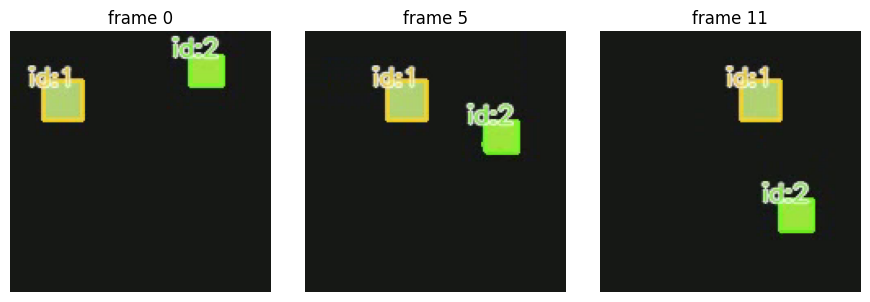

In [13]:
video_path = paths.merged_video
print(video_path, f"({video_path.stat().st_size / 1024:.0f} KB)")

try:
    display(Video(str(video_path), embed=True, html_attributes="controls loop"))
except Exception as e:
    print("Inline playback unavailable here:", e)

cap = cv2.VideoCapture(str(video_path))
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, frame_no in zip(axes, [0, 5, 11]):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
    ok, frame = cap.read()
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {frame_no}")
    ax.axis("off")
cap.release()
plt.tight_layout()
plt.show()


## 10. Reload saved masks

`--save-masks` / `save_masks=True` persists every non-empty object mask,
bit-packed, into `<clip>_masks.npz`. Cross-checking against the CSV: the
reloaded mask's pixel count should equal that row's `area_px`.


In [14]:
from traceme.sam2.io import _unpack_mask

masks = np.load(paths.merged_masks, allow_pickle=True)
print(masks.files, "-", len(masks["global_frame_idx"]), "stored (frame, object) masks")

i = 0
gidx, oid, packed, shp = (masks[k][i] for k in ("global_frame_idx", "obj_id", "packed", "shape"))
mask = _unpack_mask(packed, tuple(shp))
csv_area = int(df[(df["global_frame_idx"] == gidx) & (df["obj_id"] == oid)]["area_px"].iloc[0])
print(f"frame {gidx}, obj {oid}: mask.sum()={mask.sum()}  csv area_px={csv_area}")
assert mask.sum() == csv_area


['global_frame_idx', 'obj_id', 'packed', 'shape'] - 24 stored (frame, object) masks
frame 0, obj 1: mask.sum()=625  csv area_px=625


## 11. Resume behavior

Re-running the same config finds every chunk already marked done and skips
straight to "resumed" — this is what makes it safe to re-submit the same
cluster job after a crash. `--no-resume` (`resume=False`) forces a full
reprocess instead.


In [15]:
t0 = time.time()
run_pipeline(cfg)
elapsed = time.time() - t0

resumed = json.loads(paths.run_summary.read_text())["resumed_chunks"]
print(f"re-run took {elapsed:.2f}s, resumed chunks: {resumed}")


15:43:32 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Pipeline config: frame_dir=/tmp/traceme_quickstart_spot1hx0/clipA output=/tmp/traceme_quickstart_spot1hx0/out_api prompt=/tmp/traceme_quickstart_spot1hx0/prompts.yaml chunk_size=6 overlap=1 fps=8 chunk_mode=auto model=tiny del_tmp=False


15:43:32 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Runtime: torch=2.9.0+cu128 cuda=12.8 cudnn=91002 visible_gpus=<unset>


15:43:32 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Runtime: no CUDA GPUs visible


15:43:32 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Model config: model=tiny cfg=/home/steve/exp/lib/python3.12/site-packages/sam2/configs/sam2.1/sam2.1_hiera_t.yaml ckpt=/home/steve/.cache/traceme/sam2/checkpoints/sam2.1_hiera_tiny.pt


15:43:32 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Precision: device=cpu tf32=False bf16=False


...

15:43:32 | INFO    | clipA | job=- | traceme.video.merge | pid=27350 host=uhh-lp | [OK] Merged 2 chunk archives → clipA_masks.npz (24 mask entries)


15:43:32 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Merging chunk masks finished in 0.006s


15:43:32 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Writing run summary finished in 0.000s


15:43:32 | INFO    | clipA | job=- | traceme.pipeline | pid=27350 host=uhh-lp | Pipeline finished successfully.


re-run took 0.13s, resumed chunks: [0, 1]


## 12. Batch runs with `traceme-gen-tasks`

For running many clips (e.g. as a SLURM array), `traceme-gen-tasks` scans a
root directory for `<clip>/<clip>.yaml` pairs and writes a `(frame_dir,
prompt_file)` TSV — one row per `traceme` invocation.


In [16]:
batch_root = work_dir / "batch_root"
for name in ("clipA", "clipB"):
    d = batch_root / name
    d.mkdir(parents=True)
    (d / f"{name}.yaml").write_text(prompts_path.read_text())

tasks_tsv = work_dir / "tasks.tsv"
!traceme-gen-tasks {batch_root} -o {tasks_tsv}
print(tasks_tsv.read_text())


Wrote 2 tasks to /tmp/traceme_quickstart_spot1hx0/tasks.tsv


/tmp/traceme_quickstart_spot1hx0/batch_root/clipA	/tmp/traceme_quickstart_spot1hx0/batch_root/clipA/clipA.yaml
/tmp/traceme_quickstart_spot1hx0/batch_root/clipB	/tmp/traceme_quickstart_spot1hx0/batch_root/clipB/clipB.yaml



## Reference

| Env var | Purpose |
|---|---|
| `SAM2_MODEL` | `tiny\|small\|base_plus\|large\|sam3` (default `large`); same as `--model` |
| `SAM2_CHECKPOINT_DIR` | Where to look for / auto-download checkpoints |
| `SAM2_CHECKPOINT` | Direct path to one checkpoint file, bypassing the dir search |
| `SAM2_ROOT` | Custom SAM2 install location (must contain `sam2/` and `checkpoints/`) |
| `TRACEME_AUTO_DOWNLOAD` | Set `0` to disable auto-download of missing SAM2 checkpoints |

Full details, SAM3 setup, and troubleshooting: see the repo's `README.md`.


In [17]:
# Everything above lives under a temp dir — uncomment to clean up.
# import shutil
# shutil.rmtree(work_dir, ignore_errors=True)
print(f"Temporary working directory: {work_dir}")


Temporary working directory: /tmp/traceme_quickstart_spot1hx0
